In [5]:

# 1. Importimi i librarive


import pandas as pd
import numpy as np

from sklearn.model_selection import (
    GroupShuffleSplit,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraritë u ngarkuan me sukses.")

Libraritë u ngarkuan me sukses.


In [6]:
# 2. Leximi i datasetit

df = pd.read_csv("../data/neurosense_cleaned.csv")

print(df.shape)
df.head()

(37575, 361)


,eeg_feature_1,eeg_feature_2,eeg_feature_3,eeg_feature_4,eeg_feature_5,eeg_feature_6,eeg_feature_7,eeg_feature_8,eeg_feature_9,eeg_feature_10,...,eye_range,eeg_stability,eye_stability,phys_activity,label,emotion,subject,session,trial,sample
0,26.791522,24.062115,21.927618,19.697461,18.626858,26.781416,24.090212,21.992052,19.634864,18.446852,...,6148.7,6.623193,0.289054,359.072631,1,Sad,10,1,1,0
1,26.791101,24.061706,21.928215,19.697127,18.626882,26.780972,24.089481,21.992834,19.634719,18.447054,...,6148.7,6.622985,0.289050,359.068374,1,Sad,10,1,1,1
2,26.791650,24.062570,21.929218,19.696753,18.626936,26.783116,24.090431,21.994368,19.634771,18.447366,...,6148.7,6.622051,0.289049,359.067974,1,Sad,10,1,1,2
3,26.793695,24.063827,21.931248,19.696395,18.626931,26.787306,24.092226,21.997363,19.634678,18.447735,...,6148.7,6.620988,0.289037,359.054303,1,Sad,10,1,1,3
4,26.794138,24.064473,21.933663,19.696645,18.627109,26.790289,24.093457,22.000899,19.635314,18.448518,...,6148.7,6.619975,0.289018,359.032246,1,Sad,10,1,1,4


In [7]:
# 3. Ndarja e features dhe target


X = df.drop(
    columns=["label", "subject", "session", "trial", "sample"],
    errors="ignore"
)

y = df["label"]

# Mbajmë vetëm kolonat numerike
X = X.select_dtypes(include=["number"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nLabel distribution:")
print(y.value_counts())

X shape: (37575, 355)
y shape: (37575,)

Label distribution:
label
0    9750
2    9735
1    9525
3    8565
Name: count, dtype: int64


In [8]:

# 4. Train/Test Split me GroupShuffleSplit


groups = df["subject"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (30060, 355)
Test shape : (7515, 355)


In [49]:
# 4. Train/Test Split me GroupShuffleSplit sipas subject

groups = df["subject"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (30060, 355)
Test shape: (7515, 355)


In [9]:
# 5. KNN bazik me StandardScaler

knn_basic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_basic_pipeline.fit(X_train, y_train)

y_pred_knn_basic = knn_basic_pipeline.predict(X_test)

c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\anaconda3\envs\dropout\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:

In [10]:
# 6. Vlerësimi i KNN bazik

knn_basic_results = {
    "Model": "KNN Basic",
    "Accuracy": accuracy_score(y_test, y_pred_knn_basic),
    "Precision": precision_score(y_test, y_pred_knn_basic, average="weighted"),
    "Recall": recall_score(y_test, y_pred_knn_basic, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_knn_basic, average="weighted")
}

print("KNN Basic Results")
for key, value in knn_basic_results.items():
    print(key, ":", value)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_basic))

KNN Basic Results
Model : KNN Basic
Accuracy : 0.24431137724550897
Precision : 0.2417995496365132
Recall : 0.24431137724550897
F1-score : 0.2254419476419924

Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.27      0.26      1950
           1       0.24      0.45      0.31      1905
           2       0.20      0.09      0.12      1947
           3       0.27      0.16      0.20      1713

    accuracy                           0.24      7515
   macro avg       0.24      0.24      0.23      7515
weighted avg       0.24      0.24      0.23      7515



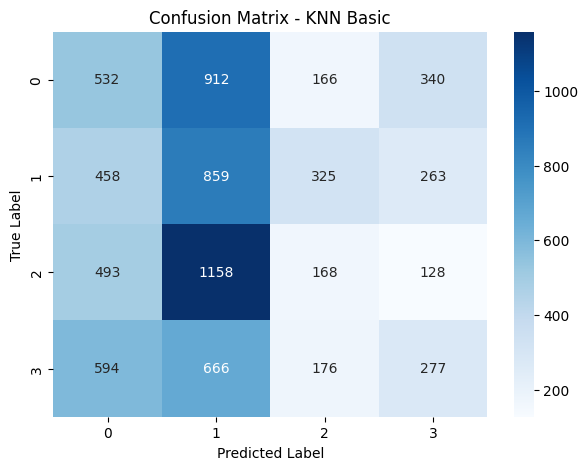

In [52]:
# 7. Confusion Matrix për KNN bazik

cm_basic = confusion_matrix(y_test, y_pred_knn_basic)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_basic, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - KNN Basic")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [11]:
# 8. Eksperimentimi me reduktimin e veçorive duke përdorur PCA

pca_results = []

for n_components in [20, 50, 100, 150]:
    pca_knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components, random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])
    
    pca_knn_pipeline.fit(X_train, y_train)
    y_pred_pca = pca_knn_pipeline.predict(X_test)
    
    pca_results.append({
        "Model": f"KNN + PCA ({n_components})",
        "PCA Components": n_components,
        "Accuracy": accuracy_score(y_test, y_pred_pca),
        "Precision": precision_score(y_test, y_pred_pca, average="weighted"),
        "Recall": recall_score(y_test, y_pred_pca, average="weighted"),
        "F1-score": f1_score(y_test, y_pred_pca, average="weighted")
    })

pca_results_df = pd.DataFrame(pca_results)
pca_results_df

,Model,PCA Components,Accuracy,Precision,Recall,F1-score
0,KNN + PCA (20),20,0.280772,0.288205,0.280772,0.263819
1,KNN + PCA (50),50,0.248969,0.244719,0.248969,0.230197
2,KNN + PCA (100),100,0.242182,0.240542,0.242182,0.224353
3,KNN + PCA (150),150,0.245775,0.243064,0.245775,0.227379


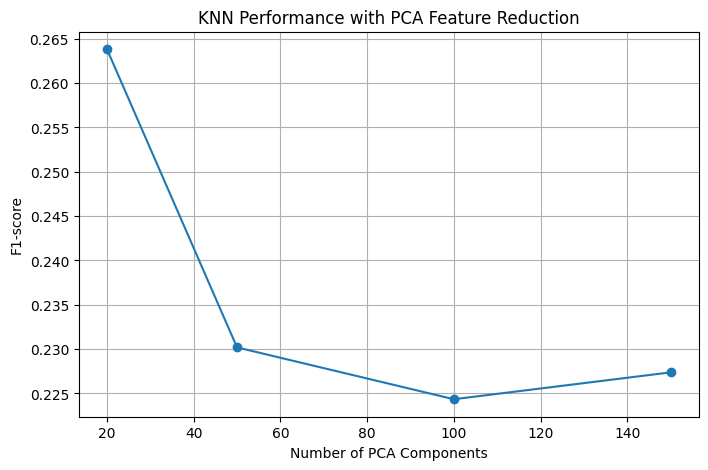

In [12]:
# 9. Vizualizimi i rezultateve të PCA

plt.figure(figsize=(8, 5))
plt.plot(
    pca_results_df["PCA Components"],
    pca_results_df["F1-score"],
    marker="o"
)

plt.title("KNN Performance with PCA Feature Reduction")
plt.xlabel("Number of PCA Components")
plt.ylabel("F1-score")
plt.grid(True)
plt.show()

In [13]:
# 10. Zgjedhja e konfigurimit më të mirë nga PCA

best_pca_result = pca_results_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

best_pca_result

Model             KNN + PCA (20)
PCA Components                20
Accuracy                0.280772
Precision               0.288205
Recall                  0.280772
F1-score                0.263819
Name: 0, dtype: object

In [14]:
# 11. Hyperparameter Tuning për KNN + PCA

knn_tuning_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=20, random_state=42)),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_search_knn = GridSearchCV(
    estimator=knn_tuning_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search_knn.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search_knn.best_params_)

print("Best CV Score:")
print(grid_search_knn.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Best CV Score:
0.24648545493647134


In [15]:
# 12. Vlerësimi final i KNN pas tuning

best_knn_model = grid_search_knn.best_estimator_

y_pred_best_knn = best_knn_model.predict(X_test)

knn_final_results = {
    "Model": "KNN + PCA + GridSearchCV",
    "Accuracy": accuracy_score(y_test, y_pred_best_knn),
    "Precision": precision_score(y_test, y_pred_best_knn, average="weighted"),
    "Recall": recall_score(y_test, y_pred_best_knn, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_best_knn, average="weighted"),
    "Best Parameters": grid_search_knn.best_params_
}

print("Final KNN Results")
for key, value in knn_final_results.items():
    print(key, ":", value)

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_best_knn))

Final KNN Results
Model : KNN + PCA + GridSearchCV
Accuracy : 0.2665335994677312
Precision : 0.25671451525810873
Recall : 0.2665335994677312
F1-score : 0.2435121215766202
Best Parameters : {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}

Final Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.35      0.33      1950
           1       0.24      0.45      0.32      1905
           2       0.28      0.19      0.23      1947
           3       0.18      0.05      0.08      1713

    accuracy                           0.27      7515
   macro avg       0.25      0.26      0.24      7515
weighted avg       0.26      0.27      0.24      7515



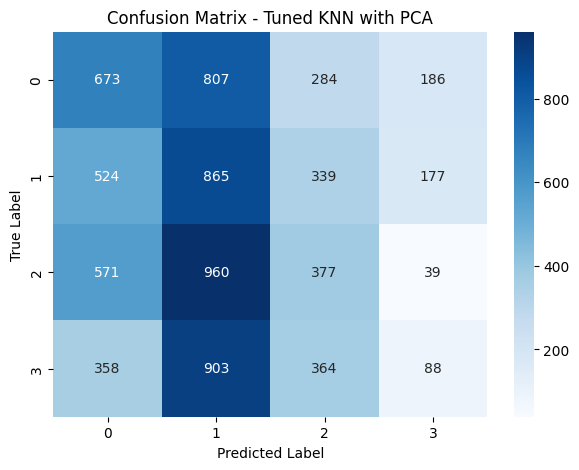

In [59]:
# 13. Confusion Matrix final

cm_final = confusion_matrix(y_test, y_pred_best_knn)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned KNN with PCA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [60]:
# 14. Ruajtja e rezultateve për comparison.ipynb

knn_results_df = pd.DataFrame([knn_final_results])

knn_results_df.to_csv("../results/tables/knn_results.csv", index=False)

knn_results_df

,Model,Accuracy,Precision,Recall,F1-score,Best Parameters
0,KNN + PCA + GridSearchCV,0.266534,0.256715,0.266534,0.243512,"{'knn__metric': 'manhattan', 'knn__n_neighbors..."


In [61]:
knn_comparison_df = pd.concat([
    pd.DataFrame([knn_basic_results]),
    pca_results_df.drop(columns=["PCA Components"]),
    pd.DataFrame([knn_final_results])
], ignore_index=True)

knn_comparison_df

,Model,Accuracy,Precision,Recall,F1-score,Best Parameters
0,KNN Basic,0.244311,0.241800,0.244311,0.225442,NaN
1,KNN + PCA (20),0.280772,0.288205,0.280772,0.263819,NaN
2,KNN + PCA (50),0.248969,0.244719,0.248969,0.230197,NaN
3,KNN + PCA (100),0.242182,0.240542,0.242182,0.224353,NaN
4,KNN + PCA (150),0.245775,0.243064,0.245775,0.227379,NaN
5,KNN + PCA + GridSearchCV,0.266534,0.256715,0.266534,0.243512,"{'knn__metric': 'manhattan', 'knn__n_neighbors..."


In [62]:
knn_comparison_df.to_csv("../results/tables/knn_comparison_results.csv", index=False)